# Boosting

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

## Import data

In [27]:
# Reading data
X_train = pd.read_csv('../data/processed/X_train_temporal_obj1.csv')
X_test = pd.read_csv('../data/processed/X_test_temporal_obj1.csv')
y_train = pd.read_csv('../data/processed/y_train_temporal_obj1.csv')
y_test = pd.read_csv('../data/processed/y_test_temporal_obj1.csv')

## Creating model and training data - XGBoost

In [ ]:
# Initialize XGBoost model
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, subsample=0.8, 
                          colsample_bytree=0.8, eval_metric='logloss', random_state=42, n_jobs=-1)

# Train the model
xgb_model.fit(X_train, y_train.values.ravel())

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## Predictions

In [29]:
# Make predictions on the test set
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

In [30]:
# Evaluate accuracy and other metrics
model_accuracy = accuracy_score(y_test, y_pred)
model_precision = precision_score(y_test, y_pred)
model_recall = recall_score(y_test, y_pred)
model_f1 = f1_score(y_test, y_pred)
model_roc_auc = roc_auc_score(y_test, y_proba)
model_cm = confusion_matrix(y_test, y_pred)
model_report = classification_report(y_test, y_pred)

In [31]:
# Showing results
model_accuracy, model_precision, model_recall, model_f1, model_roc_auc

(0.518476310557199,
 0.5264637993770852,
 0.8056858147713951,
 0.6368119776394637,
 0.5069359065073891)

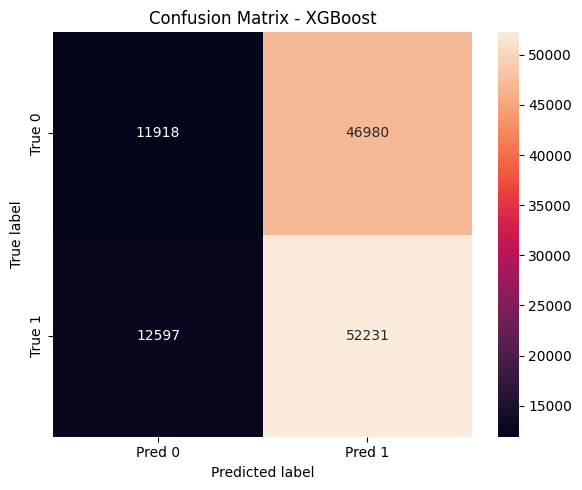

In [ ]:
# Plotting confussion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(model_cm, annot=True, fmt='d', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])

plt.title('Confusion Matrix - XGBoost')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

In [33]:
# Classification report
classification_report(y_test, y_pred, digits=3)

'              precision    recall  f1-score   support\n\n           0      0.486     0.202     0.286     58898\n           1      0.526     0.806     0.637     64828\n\n    accuracy                          0.518    123726\n   macro avg      0.506     0.504     0.461    123726\nweighted avg      0.507     0.518     0.470    123726\n'

## Optimization

In [ ]:
# Hyperparameters to test
hyperparams = {'n_estimators' : [100, 200],
               'learning_rate' : [0.05, 0.1],
               'max_depth' : [2, 3, 4],
               'min_split_loss' : [0, 0.1],
               'subsample' : [0.7, 0.8],
               'colsample_bytree' : [0.7, 0.8]}

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Initialize the grid search
grid_search = GridSearchCV(XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1), 
                           hyperparams, scoring='roc_auc', cv=tscv, n_jobs=-1)

grid_search.fit(X_train, y_train.values.ravel())

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.7, 0.8], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, ...], 'min_split_loss': [0, 0.1], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [35]:
# Best parameters and evaluation
grid_model_xgb = grid_search.best_estimator_

y_pred_opt = grid_model_xgb.predict(X_test)
y_proba_opt = grid_model_xgb.predict_proba(X_test)[:,1]

In [36]:
# Metrics for optimized model
test_accuracy = accuracy_score(y_test, y_pred_opt)
test_precision = precision_score(y_test, y_pred_opt)
test_recall = recall_score(y_test, y_pred_opt)
test_f1 = f1_score(y_test, y_pred_opt)
test_roc_auc = roc_auc_score(y_test, y_proba_opt)

In [37]:
# Showing results
test_accuracy, test_precision, test_recall, test_f1, test_roc_auc

(0.5180479446518921,
 0.5267013232514177,
 0.7908156969210834,
 0.6322858340938803,
 0.5062516580546943)

## Creating model and training data - Gradient Boosting

In [38]:
# Initialize Gradient Boosting model
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, subsample=0.8, random_state=42)

# Train the model
gb_model.fit(X_train, y_train.values.ravel())

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## Predictions

In [39]:
# Make predictions on the test set
y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:, 1]

In [40]:
# Evaluate accuracy and other metrics
model_accuracy_gb = accuracy_score(y_test, y_pred_gb)
model_precision_gb = precision_score(y_test, y_pred_gb)
model_recall_gb = recall_score(y_test, y_pred_gb)
model_f1_gb = f1_score(y_test, y_pred_gb)
model_roc_auc_gb = roc_auc_score(y_test, y_proba_gb)
cm_gb = confusion_matrix(y_test, y_pred_gb)

In [41]:
# Showing results
model_accuracy_gb, model_precision_gb, model_recall_gb, model_f1_gb, model_roc_auc_gb

(0.5184520634304834,
 0.5263142060610922,
 0.8095730240019745,
 0.6379128024989973,
 0.5050863461488471)

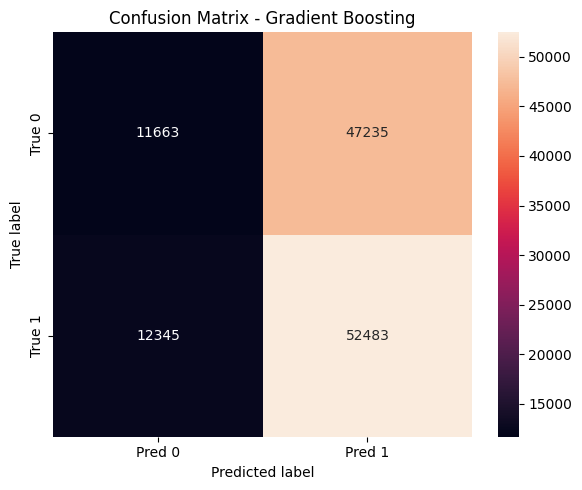

In [ ]:
# Plotting confussion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_gb, annot=True, fmt='d', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])

plt.title('Confusion Matrix - Gradient Boosting')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

In [43]:
# Classification report
classification_report(y_test, y_pred_gb, digits=3)

'              precision    recall  f1-score   support\n\n           0      0.486     0.198     0.281     58898\n           1      0.526     0.810     0.638     64828\n\n    accuracy                          0.518    123726\n   macro avg      0.506     0.504     0.460    123726\nweighted avg      0.507     0.518     0.468    123726\n'

## Optimization

In [ ]:
# Hyperparameters to test
hyperparams_gb = {'n_estimators' : [100, 200],
                  'learning_rate' : [0.05, 0.1],
                  'max_depth' : [2, 3, 4],
                  'subsample' : [0.7, 0.8],
                  'max_features' : ['sqrt', 'log2']}

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Initialize the grid search
grid_search_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), 
                              hyperparams_gb, scoring='roc_auc', cv=tscv, n_jobs=-1)

grid_search_gb.fit(X_train, y_train.values.ravel())

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, ...], 'max_features': ['sqrt', 'log2'], 'n_estimators': [100, 200], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [45]:
# Best parameters and evaluation
grid_model_gb = grid_search_gb.best_estimator_

y_pred_gb_opt = grid_model_gb.predict(X_test)
y_proba_gb_opt = grid_model_gb.predict_proba(X_test)[:,1]

In [46]:
# Metrics for optimized model
test_accuracy_gb = accuracy_score(y_test, y_pred_gb_opt)
test_precision_gb = precision_score(y_test, y_pred_gb_opt)
test_recall_gb = recall_score(y_test, y_pred_gb_opt)
test_f1_gb = f1_score(y_test, y_pred_gb_opt)
test_roc_auc_gb = roc_auc_score(y_test, y_proba_gb_opt)

In [47]:
# Showing results
test_accuracy_gb, test_precision_gb, test_recall_gb, test_f1_gb, test_roc_auc_gb

(0.5177893086335936,
 0.5270539193095647,
 0.7762232368729561,
 0.6278196426789101,
 0.5064995770207759)

### Conclusión
El modelo Gradient Boosting optimizado presenta un rendimiento muy similar al obtenido con XGBoost, con métricas cercanas al azar y un ROC AUC ligeramente superior a 0.50. Aunque el modelo logra un alto recall para la clase positiva, esto se consigue a costa de un elevado número de falsos positivos, lo que limita su utilidad práctica. La comparación entre distintos algoritmos muestra que el bajo rendimiento no depende del modelo empleado, sino de la dificultad intrínseca del problema y del elevado nivel de ruido presente en los datos financieros. Por tanto, el enfoque utilizado no resulta adecuado para realizar predicciones fiables de subidas diarias del mercado.

### Conclusion
The optimized Gradient Boosting model shows performance very similar to XGBoost, with metrics close to random guessing and a ROC AUC slightly above 0.50. While the model achieves a high recall for the positive class, this comes at the cost of a large number of false positives, significantly limiting its practical usefulness. The consistent results across multiple models indicate that the limited performance is not due to the choice of algorithm, but rather to the inherent difficulty of the task and the high level of noise in financial time-series data. Therefore, this approach is not suitable for making reliable daily stock price movement predictions.